# **Data Understanding (Klasifikasi Time Series - Dataset BME)**

## 1. Gambaran Umum Dataset BME

Dataset BME (Begin–Middle–End) merupakan dataset deret waktu (time series) sintetis dan univariat yang digunakan sebagai salah satu benchmark dalam UCR Time Series Classification Archive. Dataset ini dikembangkan oleh peneliti di *Laboratoire d’Informatique de Grenoble (LIG), Université Grenoble Alpes*, kemudian diadopsi ke dalam koleksi UCR sebagai salah satu problem klasifikasi deret waktu berdimensi satu.

Tujuan utama dari dataset BME adalah menyediakan contoh dataset yang sederhana namun memiliki struktur pola yang jelas, sehingga sangat cocok untuk menguji algoritma klasifikasi deret waktu, terutama model yang perlu mengenali pergeseran pola sepanjang sumbu waktu (*time-shift*).


## 2. Struktur dan Karakteristik Data

Setiap sampel pada dataset BME memiliki karakteristik sebagai berikut:

- **Jenis data**: deret waktu univariat (satu fitur sinyal per sampel).  
- **Panjang deret waktu**: setiap sampel memiliki panjang 128 titik waktu (*time steps*).  
- **Tipe nilai**: berupa bilangan real (float) yang merepresentasikan amplitudo sinyal.  
- **Jumlah kelas**: terdapat 3 kelas, yaitu:
  - **Begin**
  - **Middle**
  - **End**

- **Pembagian data standar (dari UCR Archive)**:
  - **30 sampel** untuk *training*
  - **150 sampel** untuk *testing*


## 3. Pola Sinyal pada Tiap Kelas

Hal yang menarik dari dataset BME adalah bahwa **ketiga kelas memiliki bagian tengah (plateau -> Bagian sinyal yang relatif datar, stabil, atau tidak banyak berubah.) yang relatif mirip**, sehingga bagian tersebut tidak terlalu informatif untuk membedakan kelas. Justru pola yang membedakan ketiga kelas terletak pada keberadaan dan posisi puncak (peak) dalam sinyal.

Berikut penjelasan pola tiap kelas:

### **1. Kelas “Begin”**
- Mempunyai puncak kecil bernilai positif yang muncul di awal deret waktu.  

### **2. Kelas “Middle”**
- Tidak memiliki puncak mencolok di awal ataupun akhir deret waktu.  

### **3. Kelas “End”**
- Memiliki puncak positif yang muncul mendekati akhir deret waktu.  

Dengan struktur seperti ini, dataset BME sangat berguna untuk menilai apakah model klasifikasi time series mampu:
- membedakan posisi pola  
- memahami perbedaan bentuk sinyal meskipun sebagian besar sinyal terlihat mirip.



## 4. Eksplorasi Data (EDA)

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df_train = pd.read_csv('BME_TRAIN.csv')
df_test = pd.read_csv('BME_TEST.csv')

print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)
print(f"Ukuran data training: {df_train.shape}")
print(f"Ukuran data testing: {df_test.shape}")

INFORMASI DATASET
Ukuran data training: (30, 129)
Ukuran data testing: (8, 129)


### 2.1 Melihat struktur data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(df_train.head())

       att1      att2      att3      att4      att5      att6      att7  \
0  0.037765  0.000253  0.003977  0.020764  0.021731  0.114000  0.414000   
1  0.000425  0.020982  0.002526  0.020118  0.037074  0.034782  0.083000   
2  0.019856  0.003677  0.035077  0.011545  0.127000  0.462000  0.797000   
3 -0.005805  0.002666  0.021716  0.016958  0.027037  0.003596  0.012597   
4  0.031380  0.057092  0.047269  0.043872  0.026902  0.037878  0.032261   

       att8      att9     att10  ...    att120    att121    att122    att123  \
0  0.718000  0.889000  0.969000  ...  0.022831  0.013387  0.038907  0.039188   
1  0.317000  0.550000  0.680000  ...  0.011228  0.025040  0.044365  0.043476   
2  0.985000  1.074000  0.983000  ...  0.017686  0.046659  0.005717  0.019496   
3  0.090000  0.338000  0.581000  ...  0.021472  0.005443  0.045583  0.001084   
4  0.011465  0.024362  0.039082  ...  0.019191  0.044964  0.014297  0.005419   

     att124    att125    att126    att127    att128  target  
0  0.0

In [3]:
print("\n--- Info Data Training ---")
print(df_train. info())


--- Info Data Training ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Columns: 129 entries, att1 to target
dtypes: float64(128), int64(1)
memory usage: 30.4 KB
None


In [4]:
print("\n--- Statistik Deskriptif Data Training ---")
print(df_train. describe())


--- Statistik Deskriptif Data Training ---


            att1       att2       att3       att4       att5       att6  \
count  30.000000  30.000000  30.000000  30.000000  30.000000  30.000000   
mean    0.022363   0.022380   0.017579   0.021523   0.027460   0.038957   
std     0.016616   0.015708   0.016732   0.016017   0.024676   0.082893   
min    -0.005805   0.000253  -0.004860  -0.001702  -0.002623  -0.002771   
25%     0.009671   0.009333   0.003876   0.011388   0.012567   0.009598   
50%     0.026171   0.023152   0.013385   0.019947   0.025269   0.021027   
75%     0.034599   0.031089   0.029883   0.035779   0.038971   0.035930   
max     0.050930   0.057092   0.055518   0.049456   0.127000   0.462000   

            att7       att8       att9      att10  ...     att120     att121  \
count  30.000000  30.000000  30.000000  30.000000  ...  30.000000  30.000000   
mean    0.063086   0.097850   0.149206   0.199273  ...   0.084038   0.054656   
std     0.157943   0.228752   0.284140   0.322203  ...   0.154788   0.090493   
min 

### 2.2 Cek Missing Values

In [5]:
missing_train = df_train. isnull().sum(). sum()
missing_test = df_test. isnull().sum().sum()
print(f"Missing values di data training: {missing_train}")
print(f"Missing values di data testing: {missing_test}")

Missing values di data training: 0
Missing values di data testing: 0


### 2.3 Distribusi Kelas Target

Data Training:
target
1    10
2    10
3    10
Name: count, dtype: int64

Data Testing:
target
1    3
2    3
3    2
Name: count, dtype: int64


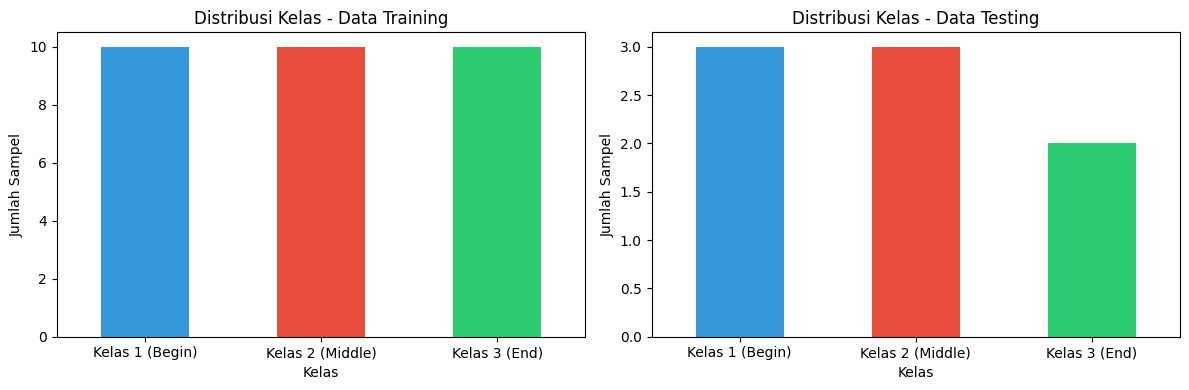

In [6]:
print("Data Training:")
print(df_train['target'].value_counts(). sort_index())
print("\nData Testing:")
print(df_test['target']. value_counts().sort_index())

# Visualisasi distribusi kelas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax1 = axes[0]
df_train['target']. value_counts().sort_index().plot(kind='bar', ax=ax1, color=['#3498db', '#e74c3c', '#2ecc71'])
ax1. set_title('Distribusi Kelas - Data Training')
ax1.set_xlabel('Kelas')
ax1.set_ylabel('Jumlah Sampel')
ax1.set_xticklabels(['Kelas 1 (Begin)', 'Kelas 2 (Middle)', 'Kelas 3 (End)'], rotation=0)

ax2 = axes[1]
df_test['target'].value_counts().sort_index(). plot(kind='bar', ax=ax2, color=['#3498db', '#e74c3c', '#2ecc71'])
ax2. set_title('Distribusi Kelas - Data Testing')
ax2.set_xlabel('Kelas')
ax2. set_ylabel('Jumlah Sampel')
ax2.set_xticklabels(['Kelas 1 (Begin)', 'Kelas 2 (Middle)', 'Kelas 3 (End)'], rotation=0)

plt.tight_layout()
plt. show()

### 2.4 Visualisasi Pola Time Series per Kelas

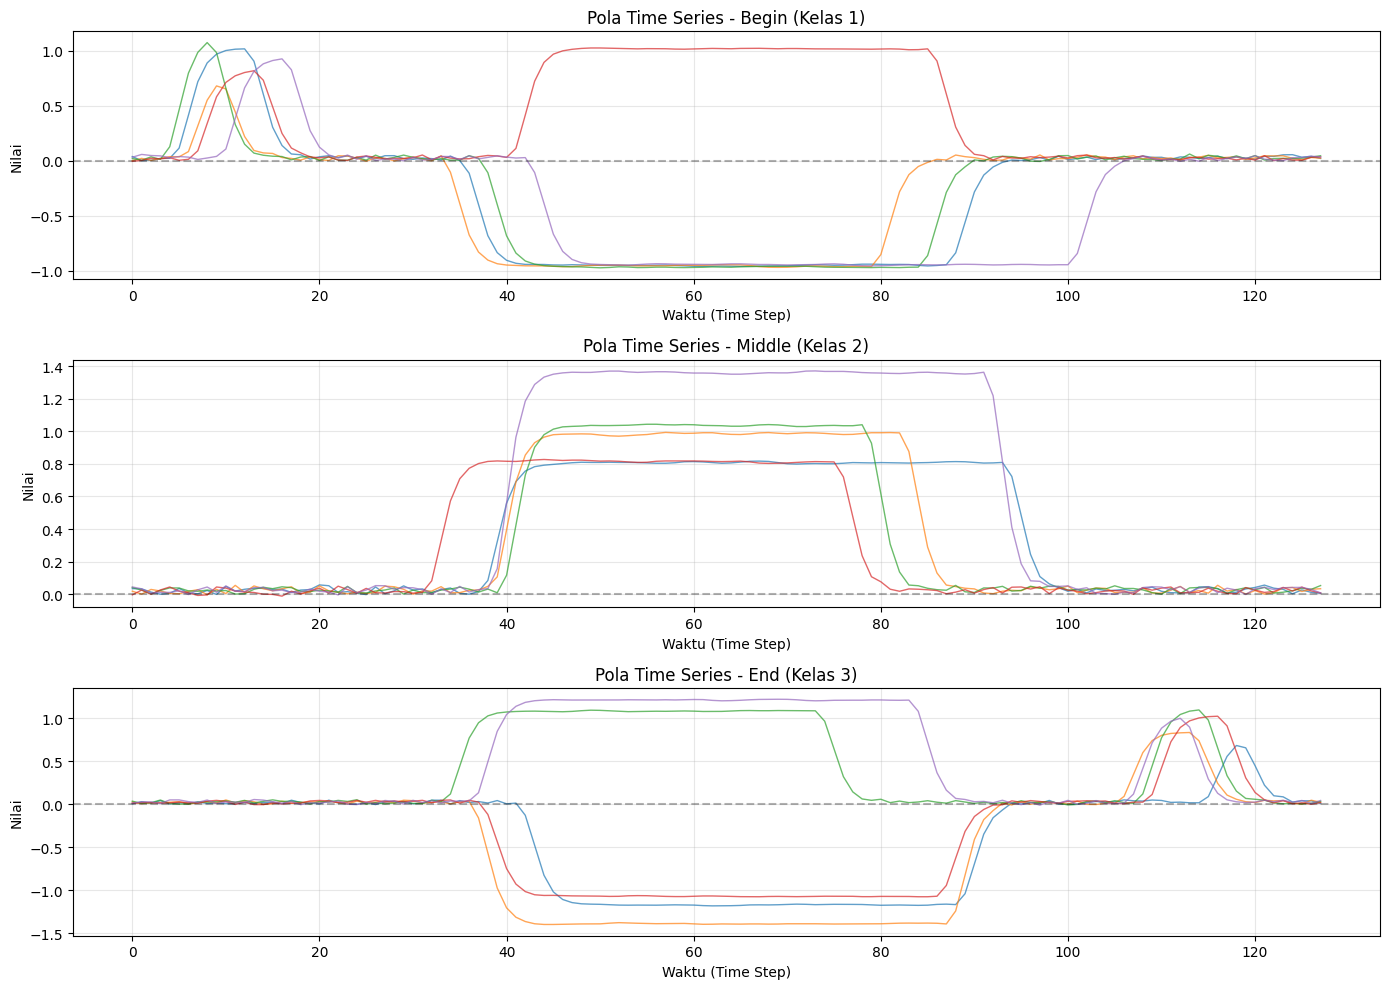

In [7]:
class_names = {1: 'Begin (Kelas 1)', 2: 'Middle (Kelas 2)', 3: 'End (Kelas 3)'}

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

for idx, kelas in enumerate([1, 2, 3]):
    ax = axes[idx]
    samples = df_train[df_train['target'] == kelas]. iloc[:5, :-1]
    
    for i in range(len(samples)):
        ax. plot(samples.iloc[i]. values, alpha=0.7, linewidth=1)
    
    ax.set_title(f'Pola Time Series - {class_names[kelas]}')
    ax.set_xlabel('Waktu (Time Step)')
    ax. set_ylabel('Nilai')
    ax.grid(True, alpha=0.3)
    ax. axhline(y=0, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt. show()


### 2.5 Rata-rata Pola Time Series per Kelas

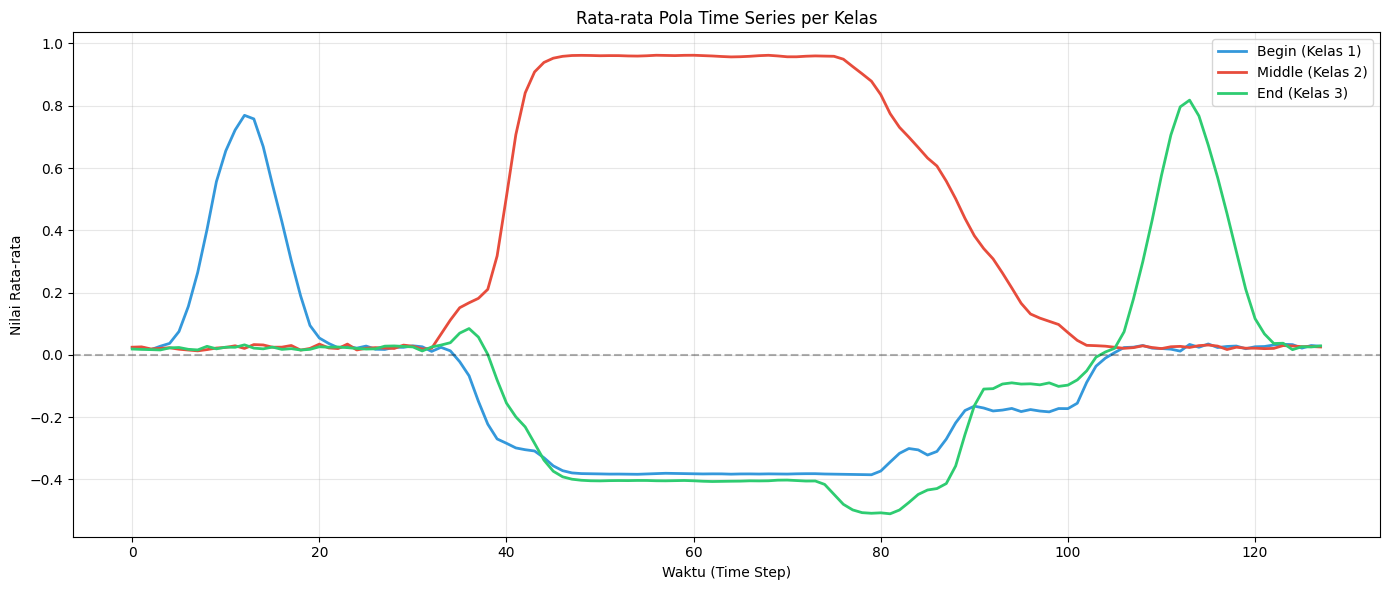

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#3498db', '#e74c3c', '#2ecc71']
for idx, kelas in enumerate([1, 2, 3]):
    mean_pattern = df_train[df_train['target'] == kelas]. iloc[:, :-1].mean()
    ax. plot(mean_pattern.values, label=class_names[kelas], color=colors[idx], linewidth=2)

ax.set_title('Rata-rata Pola Time Series per Kelas')
ax.set_xlabel('Waktu (Time Step)')
ax.set_ylabel('Nilai Rata-rata')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt. show()
